In [1]:
# This cell is tagged for removal

import os
import math
import pickle
from glob import glob

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

import aliases # important this goes first to configure PATH

from everest.window import Canvas, DataChannel as Channel
from everest.window.colourmaps import *
from everest.window import image, imop

from thesiscode.referencing import search
from thesiscode.general import *
from analysis import isovisc, arrhenius, utilities, common, analysis, visualisation

## Internal heating in the annulus

### Conductive solution

In [2]:
with open(os.path.join(aliases.storagedir, 'condhfinsulating.pkl'), mode = 'rb') as file:
    conddata = pickle.loads(file.read())
condhs, condfs = zip(*conddata['hfs'])
condhs = tuple(round(val, 1) for val in condhs)
frm = pd.DataFrame(dict(
    H = condhs, f = condfs, T = conddata['avts'], geotherm = conddata['geotherms']
    ))
frm = frm.loc[frm['H'] > 0]
frm = frm.set_index(['H', 'f'])
Hs, fs = (np.array(sorted(set(frm.index.get_level_values(level)))) for level in ('H', 'f'))
frm['h'] = frm['geotherm'].apply(lambda x: np.linspace(0, 1, len(x)))
# frm['rstar'] = frm.apply(lambda fr: r_star(fr['h'], fr.name[1]), axis = 1)
# frm['astar'] = frm.apply(lambda fr: s_star(fr['h'], fr.name[1]), axis = 1)

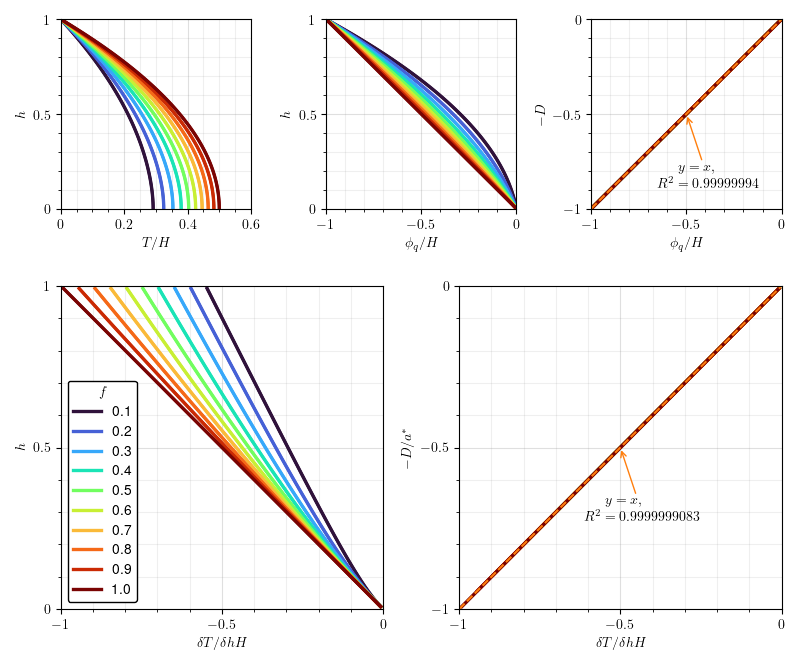

In [3]:
#| label: isocondinternal

canvas1 = Canvas(size = (8, 8/3), shape = (1, 3))
ax1 = canvas1.make_ax((0, 0))
ax2 = canvas1.make_ax((0, 1))
ax3 = canvas1.make_ax((0, 2))
# ax4 = canvas.make_ax((1, 1))
# extract = []

allx, ally = [], []

for (H, f), values in frm.iterrows():

    if f == 1:
        f = 0.99999
    h, T = values['h'], values['geotherm']

    ax1.line(
        Channel(T / H, lims = (0, 0.5), label = '$T/H$'),
        Channel(h, lims = (0, 1), label = '$h$'),
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )

    dT, hdT = analysis.derivative(T, h, n = 1)
    ax2.line(
        phichan := Channel(dT * s_star(hdT, f) / H, lims = (-1, 0), label = r"$\phi_q/H$"),
        Channel(hdT, lims = (0, 1), label = '$h$'),
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )
    ax3.line(
        phichan,
        dchan := Channel(-sub_area(hdT, f), label = r"$-D$"),
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )
    ally.extend(dchan.data)
    allx.extend(phichan.data)

# ax2.props.edges.y.label.visible = False
# ax2.props.edges.y.ticks.major.labels = []

linscore = r2_score(ally, allx)
ax3.line(
    np.linspace(-1, 0, 10),
    np.linspace(-1, 0, 10),
    color = '#ff7f0e',
    linestyle = '--',
    )
trendlabel = f"${r'y=x, \\ R^2 =' + str(round(linscore, 8))}$"
ax3.annotate(
    -0.5,
    -0.5,
    label = trendlabel,
    points = (15, -45),
    arrowprops = dict(arrowstyle = "->", color = '#ff7f0e'),
    )

canvas2 = Canvas(size = (8, 4), shape = (1, 2))
ax1 = canvas2.make_ax((0, 0))
ax2 = canvas2.make_ax((0, 1))
allx, ally = [], []
for (H, f), values in frm.iterrows():
    if f == 1:
        f = 0.99999
    h, T = values['h'], values['geotherm']
    dT, hdT = analysis.derivative(T, h, n = 1)
    ax1.line(
        xchan := Channel(dT / H, lims = (-1, 0), label = r'$\delta T / \delta h H$'),
        Channel(hdT, lims = (0, 1), label = '$h$'),
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )
    ax2.line(
        xchan,
        ychan := Channel(
            -sub_area(hdT, f) / a_star(hdT, f),
            lims = (-1, 0), label = r"$-D / {s^*}$"
            ),
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )
    ally.extend(ychan.data)
    allx.extend(xchan.data)
linscore = r2_score(ally, allx)
ax2.line(
    np.linspace(-1, 0, 10),
    np.linspace(-1, 0, 10),
    color = '#ff7f0e',
    linestyle = '--',
    )
trendlabel = f"${r'y=x, \\ R^2 =' + str(round(linscore, 10))}$"
ax2.annotate(
    -0.5,
    -0.5,
    label = trendlabel,
    points = (15, -45),
    arrowprops = dict(arrowstyle = "->", color = '#ff7f0e'),
    )
# ax2.props.edges.y.label.visible = False
# ax2.props.edges.y.ticks.major.labels = []

ax1.props.legend.set_handles_labels(
    (row[0] for row in ax1.collections[10::11]),
    (str(f) for f in fs),
    )
ax1.props.legend.title.text = '$f$'
ax1.props.legend.title.visible = True
# ax1.props.legend.mplprops['bbox_to_anchor'] = (1.75, 1.05)
# ax1.props.legend.mplprops['ncol'] = 2
ax1.props.legend.frame.colour = 'black'
ax1.props.legend.frame.visible = True

fig = imop.vstack(canvas1, canvas2)

fig

# ax2.props.legend.set_handles_labels(
#     (row[0] for row in ax1.collections[10::len(Hs)]),
#     (str(f) for f in fs),
#     )
# ax2.props.legend.title.text = 'f'
# ax2.props.legend.title.visible = True
# #     ax2.props.legend.mplprops['bbox_to_anchor'] = (1.75, 1.05)
# # ax1.props.legend.mplprops['ncol'] = 2
# ax2.props.legend.frame.colour = 'black'
# ax2.props.legend.frame.visible = True

```{figure} #isocondinternal
:name: isocondinternal_fig

Summary of the scaling behaviours of isoviscous conduction under internal heating $H$ for varying curvature parameter $f$ (colours as in previous charts). While samples of varying heat have been plotted, they do not appear in these charts due to the intentional factoring out of $H$, demonstrating that this parameter is a simple coefficient.
```

It was established previously that, for an internally heated system, the geotherm and geothermal gradient are represented by:

$$ \begin{align*}
{T(h)}_{c(\mathrm{internal})} &= \frac{H}{2} \left( 1 - h^2 \right) \\
{{T(h)}_{c(\mathrm{internal})}}^{'} &= H\cdot h
\end{align*} $$

This is intuitive because the source flux visible to each layer is proportional to the area below that layer, which goes linearly with height $h$ in a planar domain.

In the annulus, though, the proportion of the domain beneath a given height $h$ is instead represented by $D$, as we have shown. If we further assume that $H$ is non-dimensionalised so as to represent the total flux of the model (i.e. it equals $1$ for all geometries), then the flux through each layer height $h$ of the annulus must simply be:

$$
{\phi_q}(h) = -H \cdot D(h)
$$

We show that this holds exactly {numref}`isocondinternal_fig`.

As before, the geothermal gradient required to transmit this flux must account for the varying layer length ${s^*}$ - a function of $h$ and the $f$ parameter. Thus:

$$
\frac{dT}{dh} \propto \frac{\phi_q}{s^{*}} = -\frac{HD}{{s^*}}
$$

The integral with respect to $h$ yields the geotherm:

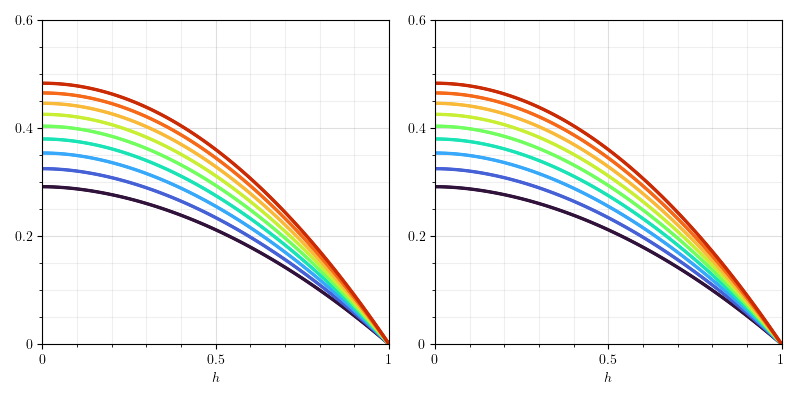

In [4]:
#| label: internalgeotherm

canvas = Canvas(size = (8, 4), shape = (1, 2))
ax1 = canvas.make_ax((0, 0))
ax2 = canvas.make_ax((0, 1))
for (H, f), values in frm.iterrows():
    if f == 1:
        continue
    h, T = values['h'], values['geotherm']
    dT, hdT = analysis.derivative(T, h, n = 1)
    astar = a_star(hdT, f)
#     phi = dT * astar / H
    D = -sub_area(hdT, f)
    ax1.line(
        hchan := Channel(h, lims = (0, 1), label = '$h$'),
        T / H,
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )
    ax2.line(
        hchan,
        T / H ,
        color = cmap(f, fs, style = 'turbo'),
        linewidth = H / 5
        )
# ax2.props.edges.y.label.visible = False
# ax2.props.edges.y.ticks.major.labels = []
canvas

```{figure} #internalgeotherm
:name: internalgeotherm_fig

The conductive geotherm under internal heating.
```

### Mixed heating in the annulus

#### Conductive solution

In [5]:
with open(os.path.join(aliases.storagedir, 'condhfmixed.pkl'), mode = 'rb') as file:
    conddata = pickle.loads(file.read())
condhs, condfs = zip(*conddata['hfs'])
condhs = tuple(round(val, 1) for val in condhs)
frm = pd.DataFrame(dict(H = condhs, f = condfs, T = conddata['avts'], geotherm = conddata['geotherms']))
frm = frm.set_index(['H', 'f'])
Hs, fs = (np.array(sorted(set(frm.index.get_level_values(level)))) for level in ('H', 'f'))